# Perception vs Reality

#### Project Idea

The aim of this project is to look at the public percepction of crime vs the actual crime statistics.
I used sourced data from: 
- The Office of National Statistics datasets
    - using:
        - Perceptions criminal justice system (CSEW open data table)
        - Perceptions other (CSEW open data table)
- Data.Police.uk API
    - specifically requesting crime data for 2024 to match the ONS Dataset
    - requesting force data for South Yorkshire, West Yorkshire and North Yorkshire

#### Technology Used

This project uses:
- Pandas
- NumPy
- API data retrieval
- Dataset useage
- Matplotlib and Seaborn for visualisation
- Python
- Juptyer Notebooks



In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from time import sleep

### Importing data from API

In [3]:
# Define months and forces
months_2024 = [f"2024-{str(m).zfill(2)}" for m in range(1, 13)]
forces = {
    'south-yorkshire': 'South Yorkshire',
    'west-yorkshire': 'West Yorkshire',
    'north-yorkshire': 'North Yorkshire'
}
base_url = "https://data.police.uk/api/crimes-no-location"

# Fetching the data
all_data = []

for force_code, force_name in forces.items():
    for month in months_2024:
        params = {
            'category': 'all-crime',
            'force': force_code,
            'date': month
        }
        response = requests.get(base_url, params=params)

        if response.status_code == 200:
            data = response.json()
            for record in data:
                record['force_name'] = force_name
                record['month'] = month
            all_data.extend(data)
            print(f"Retrieved {len(data)} records for {force_name} in {month}")
        else:
            print(f"Failed to retrieve data for {force_name} in {month} (status code: {response.status_code})")

        sleep(0.2)  # Pause for 0.2 seconds to stay under the rate limit


Retrieved 711 records for South Yorkshire in 2024-01
Retrieved 631 records for South Yorkshire in 2024-02
Retrieved 687 records for South Yorkshire in 2024-03
Retrieved 663 records for South Yorkshire in 2024-04
Retrieved 665 records for South Yorkshire in 2024-05
Retrieved 663 records for South Yorkshire in 2024-06
Retrieved 686 records for South Yorkshire in 2024-07
Retrieved 718 records for South Yorkshire in 2024-08
Retrieved 671 records for South Yorkshire in 2024-09
Retrieved 757 records for South Yorkshire in 2024-10
Retrieved 689 records for South Yorkshire in 2024-11
Retrieved 675 records for South Yorkshire in 2024-12
Retrieved 316 records for West Yorkshire in 2024-01
Retrieved 347 records for West Yorkshire in 2024-02
Retrieved 351 records for West Yorkshire in 2024-03
Retrieved 316 records for West Yorkshire in 2024-04
Retrieved 301 records for West Yorkshire in 2024-05
Retrieved 309 records for West Yorkshire in 2024-06
Retrieved 272 records for West Yorkshire in 2024-07


In [4]:
# Convert to DataFrame
crime_df = pd.DataFrame(all_data)

# Keep only key columns: force name, month, and crime category
crime_df = crime_df[['force_name', 'month', 'category']]

# Save to CSV
crime_df.to_csv('yorkshire_crime_2024.csv', index=False)

In [5]:
# Load the saved CSV file to verify
yorkshire_crime_2024 = pd.read_csv('yorkshire_crime_2024.csv')

print(yorkshire_crime_2024.head())
print(yorkshire_crime_2024.shape)

        force_name    month       category
0  South Yorkshire  2024-01  bicycle-theft
1  South Yorkshire  2024-01  bicycle-theft
2  South Yorkshire  2024-01  bicycle-theft
3  South Yorkshire  2024-01  bicycle-theft
4  South Yorkshire  2024-01       burglary
(12195, 3)


In [6]:
# Clean the category names
yorkshire_crime_2024['category'] = yorkshire_crime_2024['category'].str.replace('-', ' ').str.title()
yorkshire_crime_2024.head()


,force_name,month,category
0,South Yorkshire,2024-01,Bicycle Theft
1,South Yorkshire,2024-01,Bicycle Theft
2,South Yorkshire,2024-01,Bicycle Theft
3,South Yorkshire,2024-01,Bicycle Theft
4,South Yorkshire,2024-01,Burglary


In [7]:
yorkshire_crime_2024.dtypes

force_name    object
month         object
category      object
dtype: object

In [8]:
# Count crime by category and force per month
# Create a pivot table
crime_pivot = yorkshire_crime_2024.pivot_table(
    index=['month', 'force_name'],
    columns='category',
    aggfunc='size',
    fill_value=0
).reset_index()

# Convert 'month' from '2024-01' to full month name (e.g., 'January')
crime_pivot['month'] = pd.to_datetime(crime_pivot['month']).dt.strftime('%B')

# Optional: ensure chronological month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
crime_pivot['month'] = pd.Categorical(crime_pivot['month'], categories=month_order, ordered=True)
crime_pivot = crime_pivot.sort_values('month')

# View the pivot table
print(crime_pivot.head())


category     month       force_name  Anti Social Behaviour  Bicycle Theft  \
0          January  North Yorkshire                     13              1   
1          January  South Yorkshire                      0              4   
2          January   West Yorkshire                     14              1   
3         February  North Yorkshire                     13              0   
4         February  South Yorkshire                      0              5   

category  Burglary  Criminal Damage Arson  Drugs  Other Crime  Other Theft  \
0                2                      3      0            1            1   
1               66                     56     55           17           37   
2                7                     21     27           21           29   
3                0                      1      4            0            1   
4               64                     62     40           16           33   

category  Possession Of Weapons  Public Order  Robbery  Shoplifting 

In [9]:
crime_pivot_total = yorkshire_crime_2024.pivot_table(
    index='category'
    , columns='force_name',
    aggfunc='size',
    fill_value=0
).reset_index()
# View the total crime counts by category and force
print(crime_pivot_total.head())

force_name               category  North Yorkshire  South Yorkshire  \
0           Anti Social Behaviour              204                1   
1                   Bicycle Theft                4               42   
2                        Burglary                7              690   
3           Criminal Damage Arson               16              689   
4                           Drugs               16              569   

force_name  West Yorkshire  
0                      283  
1                       21  
2                       78  
3                      201  
4                      232  


C:\Users\ickle\AppData\Local\Temp\ipykernel_15628\1644517210.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=crime_pivot_melted, x='month', y='count', hue='force_name', ci=None, palette='Set1')


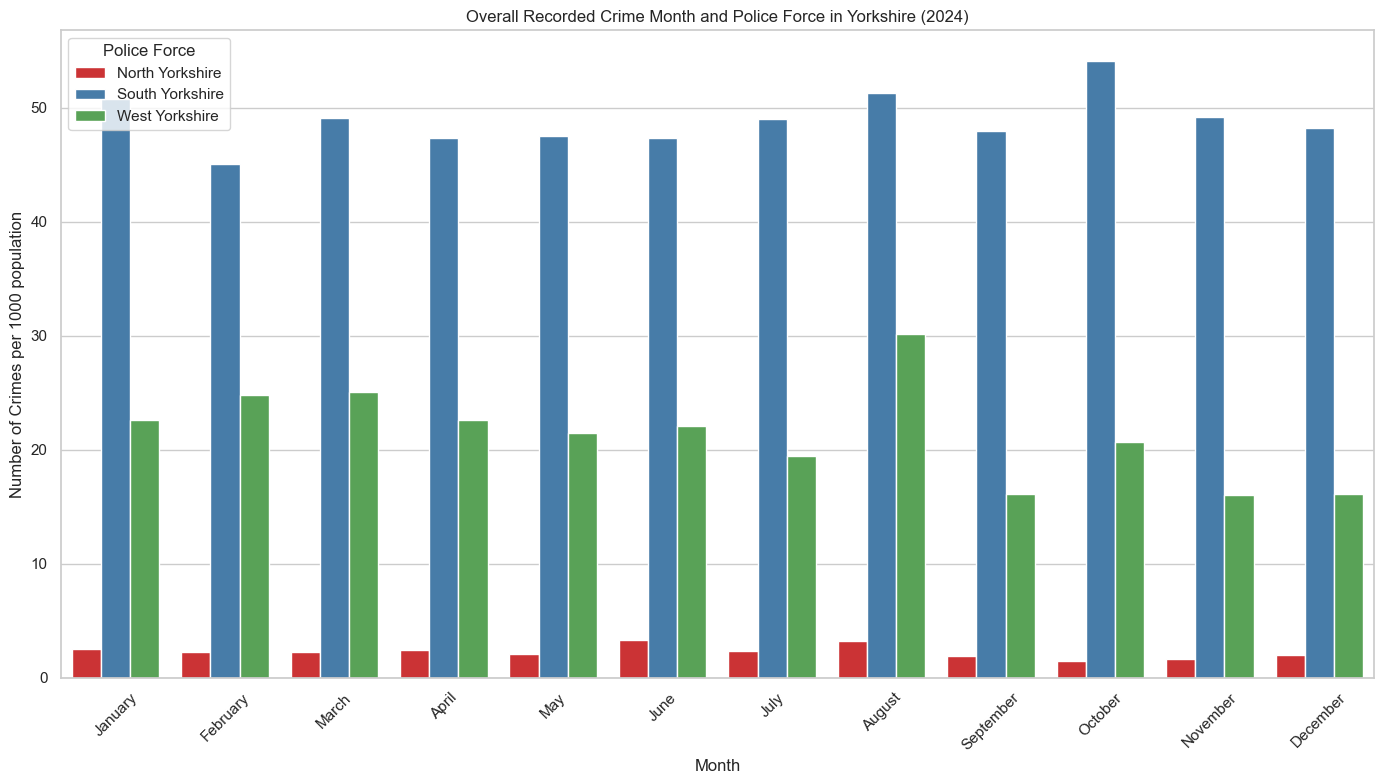

In [10]:
# Reshape the data for plotting
crime_pivot_melted = crime_pivot.melt(
	id_vars=['month', 'force_name'], 
	var_name='category', 
	value_name='count'
)

# Create a plot by month and force
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
sns.barplot(data=crime_pivot_melted, x='month', y='count', hue='force_name', ci=None, palette='Set1')   
plt.title('Overall Recorded Crime Month and Police Force in Yorkshire (2024)')
plt.xlabel('Month')
plt.ylabel('Number of Crimes per 1000 population')
plt.xticks(rotation=45)
plt.legend(title='Police Force')
plt.tight_layout()
plt.savefig('images/overall_crime_by_month.png', dpi=300, bbox_inches='tight')
plt.show()


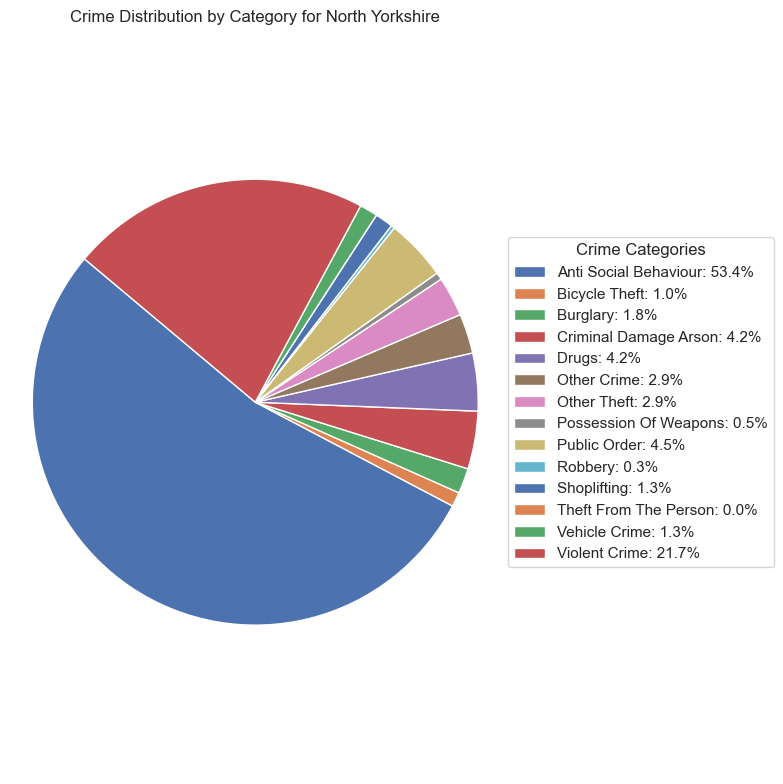

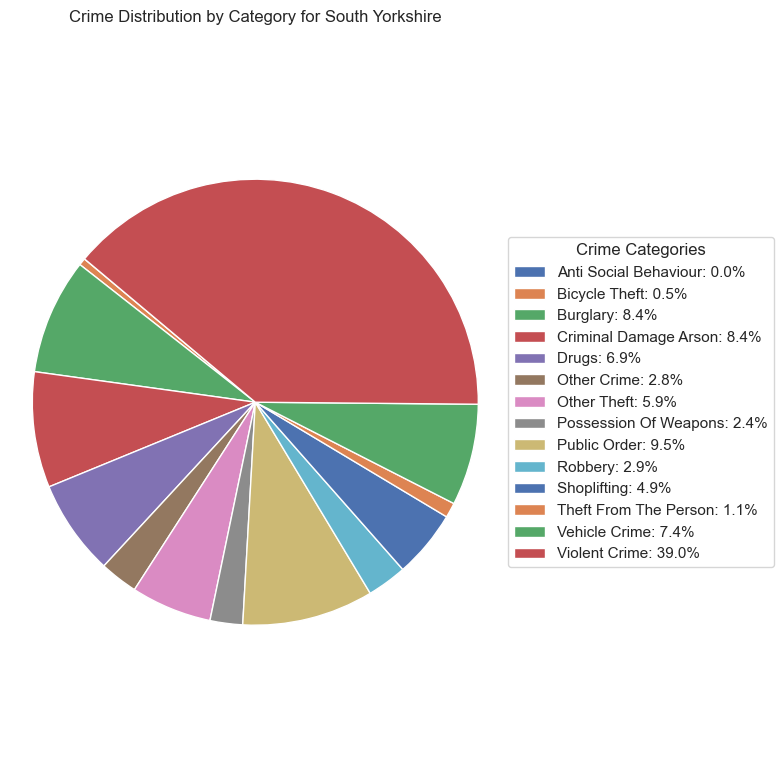

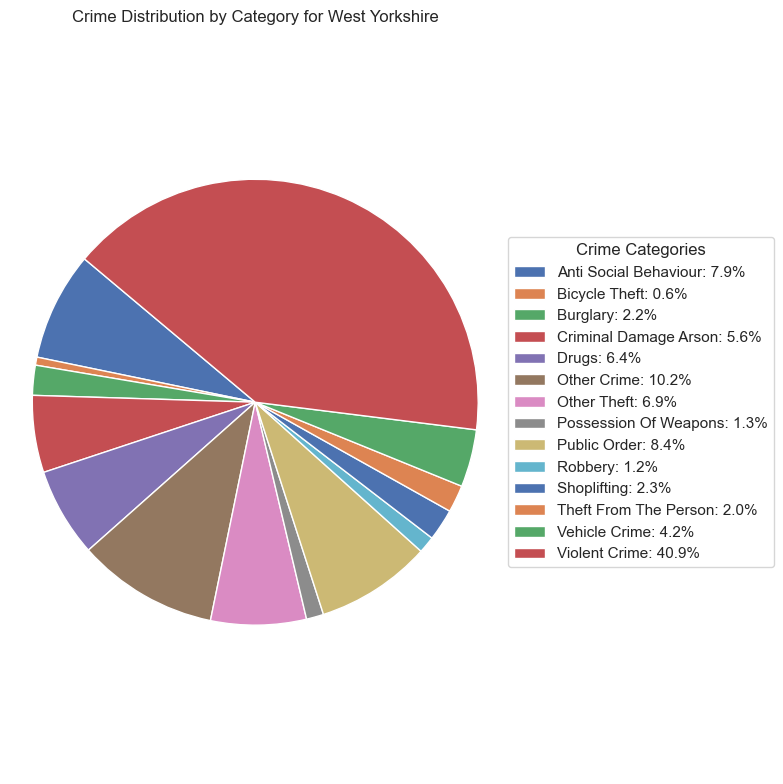

In [11]:
# Create 3 pie charts for each force
forces_list = ['North Yorkshire', 'South Yorkshire', 'West Yorkshire']  # Columns representing forces
for force in forces_list:
    plt.figure(figsize=(8, 8))
    force_data = crime_pivot_total[['category', force]]  # Select category and the force column
    wedges, texts = plt.pie(
        force_data[force], 
        labels=None,  # Remove labels from the pie chart
        startangle=140, 
        autopct=None  # Remove percentages
    )
    plt.title(f'Crime Distribution by Category for {force}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

    # Add legend with percentages
    legend_labels = [f"{cat}: {pct:.1f}%" for cat, pct in zip(force_data['category'], 
                                                              (force_data[force] / force_data[force].sum()) * 100)]
    plt.legend(wedges, legend_labels, title="Crime Categories", loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.savefig(f'images/crime_distribution_{force.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()


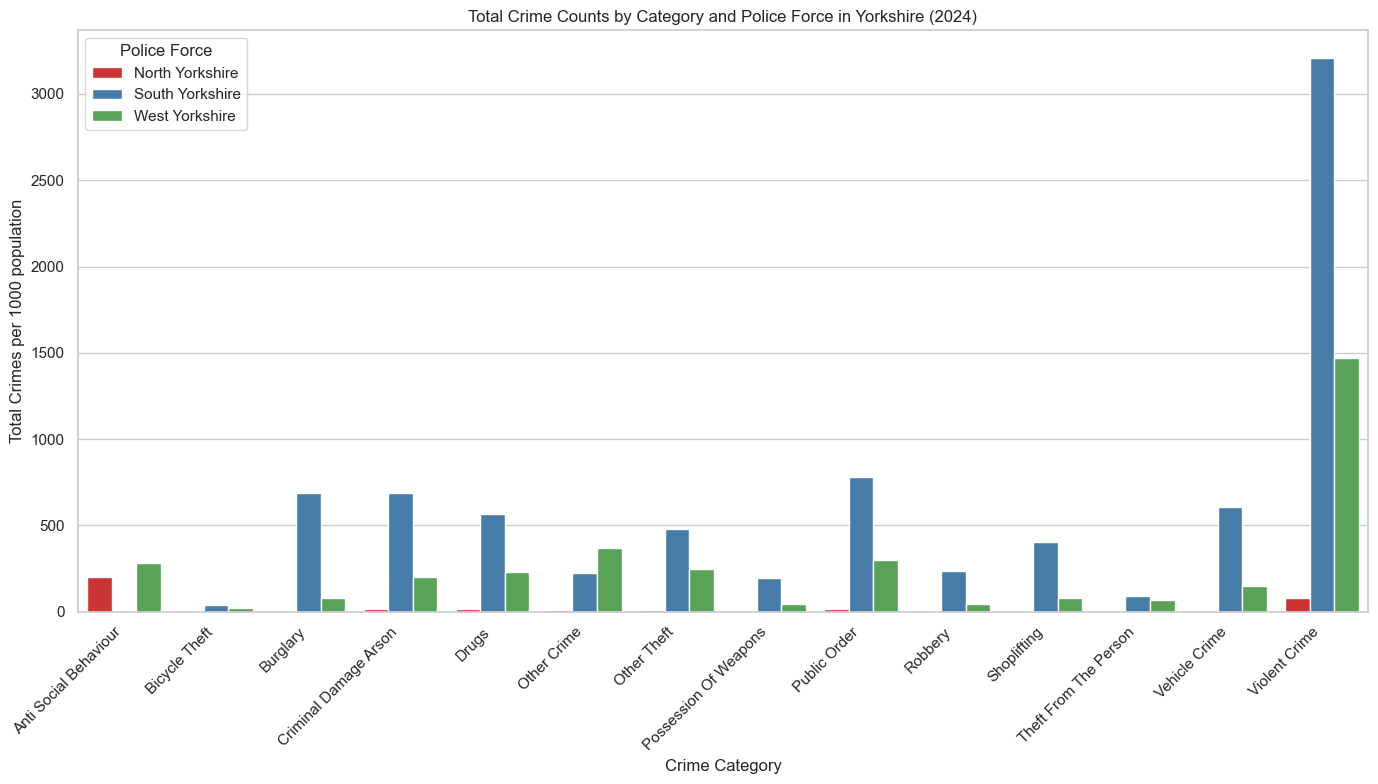

In [29]:
# Create a bar plot for total crime counts by category and police force
plt.figure(figsize=(14, 8))
sns.barplot(data=crime_pivot_total.melt(id_vars='category', var_name='force_name', value_name='count'),
            x='category', y='count', hue='force_name',palette='Set1', dodge=True)

plt.title('Total Crime Counts by Category and Police Force in Yorkshire (2024)')
plt.xlabel('Crime Category')
plt.ylabel('Total Crimes per 1000 population')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Police Force')
plt.tight_layout()
plt.savefig('images/total_crime_by_category_and_force.png', dpi=300, bbox_inches='tight')
plt.show()


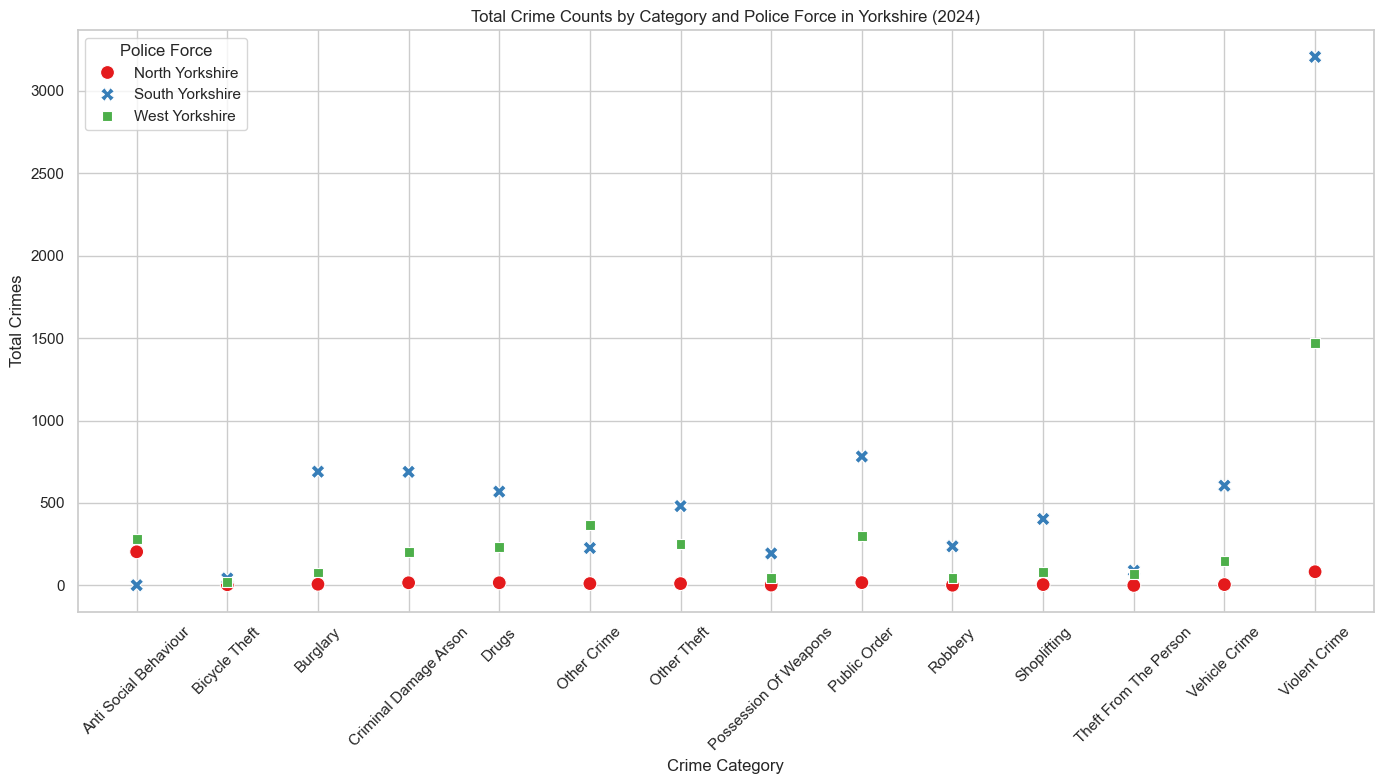

In [13]:
# Create a scatter plot for total crime counts by category and police force
plt.figure(figsize=(14, 8)) 
sns.scatterplot(data=crime_pivot_total.melt(id_vars='category', var_name='force_name', value_name='count'),
                x='category', y='count', hue='force_name', style='force_name', s=100, palette='Set1')
plt.title('Total Crime Counts by Category and Police Force in Yorkshire (2024)')
plt.xlabel('Crime Category')
plt.ylabel('Total Crimes')
plt.xticks(rotation=45)
plt.legend(title='Police Force')
plt.tight_layout()
plt.savefig('images/total_crime_scatter_by_category_and_force.png', dpi=300, bbox_inches='tight')
plt.show()


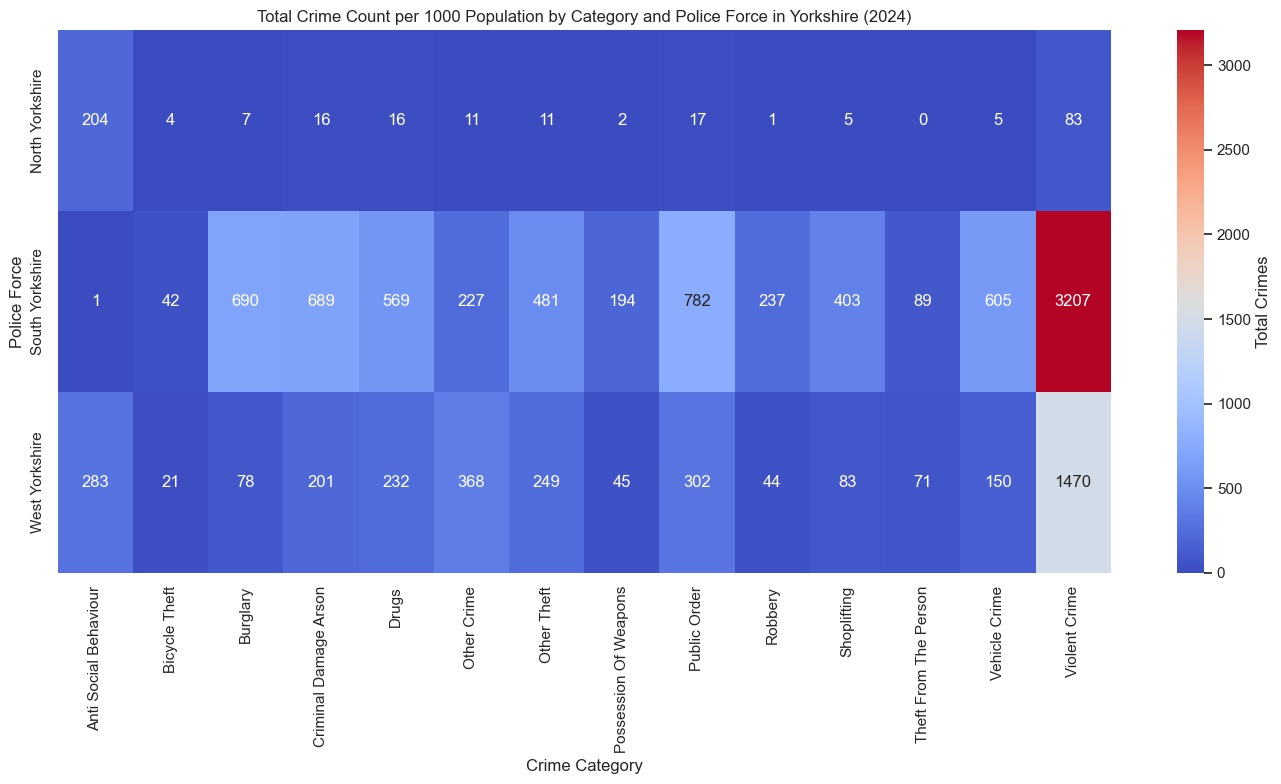

In [14]:

# Create a heatmap for total crime counts by category and police force
plt.figure(figsize=(14, 8))


sns.heatmap(crime_pivot_total.set_index('category').T, annot=True, fmt='d', cmap=sns.color_palette("coolwarm", as_cmap=True), cbar_kws={'label': 'Total Crimes'})
plt.title('Total Crime Count per 1000 Population by Category and Police Force in Yorkshire (2024)')
plt.xlabel('Crime Category')
plt.ylabel('Police Force')
plt.xticks()
plt.tight_layout()
plt.savefig('images/total_crime_heatmap_by_category_and_force.png', dpi=300, bbox_inches='tight')
plt.show()


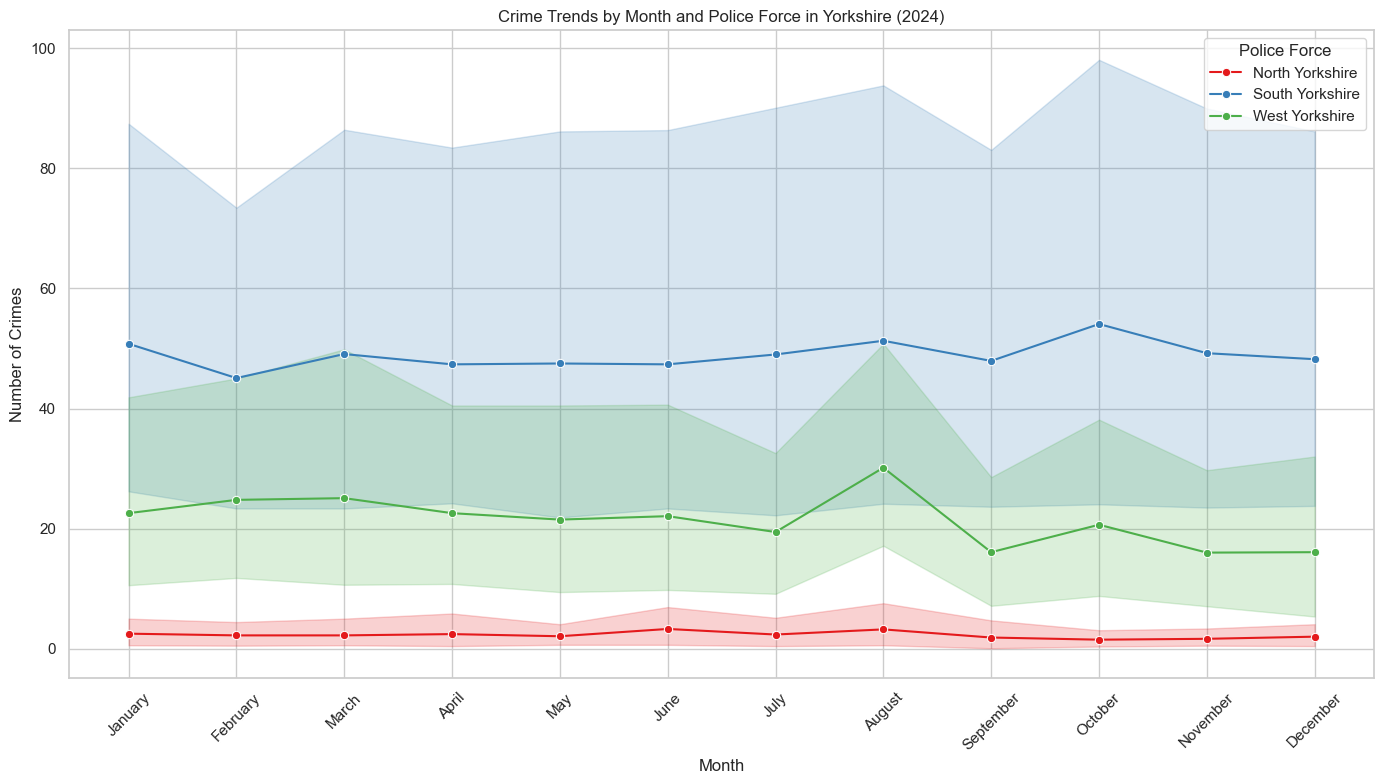

In [15]:
# Create a line plot for total crime counts by category and police force
plt.figure(figsize=(14, 8))
sns.lineplot(data=crime_pivot_melted, x='month', y='count', hue='force_name', marker='o', palette='Set1')
plt.title('Crime Trends by Month and Police Force in Yorkshire (2024)')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.legend(title='Police Force')
plt.tight_layout()
plt.savefig('images/crime_trends_by_month_and_force.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
perceptions_df = pd.read_csv('Perceptions_Data_Yorkshire.csv')
perceptions_df

,Year,Age,Characteristic,Estimate,MeasurementLabel,CrimeCategory
0,2024,16-24,Yorkshire and The Humber,0.25%,Perceived problem with abandoned or burnt out ...,anti-social-behaviour
1,2024,16+,Yorkshire and The Humber,2.46%,Perceived problem with abandoned or burnt out ...,anti-social-behaviour
2,2024,25-34,Yorkshire and The Humber,0.8%,Perceived problem with abandoned or burnt out ...,anti-social-behaviour
3,2024,35-44,Yorkshire and The Humber,4.52%,Perceived problem with abandoned or burnt out ...,anti-social-behaviour
4,2024,45-54,Yorkshire and The Humber,5.32%,Perceived problem with abandoned or burnt out ...,anti-social-behaviour
...,...,...,...,...,...,...
331,2024,35-44,Yorkshire and The Humber,21.95%,Perceived problem with vandalism and graffiti ...,criminal-damage-arson
332,2024,45-54,Yorkshire and The Humber,12.68%,Perceived problem with vandalism and graffiti ...,criminal-damage-arson
333,2024,55-64,Yorkshire and The Humber,5.21%,Perceived problem with vandalism and graffiti ...,criminal-damage-arson
334,2024,65-74,Yorkshire and The Humber,4.89%,Perceived problem with vandalism and graffiti ...,criminal-damage-arson


In [17]:
# Clean the category names
perceptions_df['CrimeCategory'] = perceptions_df['CrimeCategory'].str.replace('-', ' ').str.title()
perceptions_df

,Year,Age,Characteristic,Estimate,MeasurementLabel,CrimeCategory
0,2024,16-24,Yorkshire and The Humber,0.25%,Perceived problem with abandoned or burnt out ...,Anti Social Behaviour
1,2024,16+,Yorkshire and The Humber,2.46%,Perceived problem with abandoned or burnt out ...,Anti Social Behaviour
2,2024,25-34,Yorkshire and The Humber,0.8%,Perceived problem with abandoned or burnt out ...,Anti Social Behaviour
3,2024,35-44,Yorkshire and The Humber,4.52%,Perceived problem with abandoned or burnt out ...,Anti Social Behaviour
4,2024,45-54,Yorkshire and The Humber,5.32%,Perceived problem with abandoned or burnt out ...,Anti Social Behaviour
...,...,...,...,...,...,...
331,2024,35-44,Yorkshire and The Humber,21.95%,Perceived problem with vandalism and graffiti ...,Criminal Damage Arson
332,2024,45-54,Yorkshire and The Humber,12.68%,Perceived problem with vandalism and graffiti ...,Criminal Damage Arson
333,2024,55-64,Yorkshire and The Humber,5.21%,Perceived problem with vandalism and graffiti ...,Criminal Damage Arson
334,2024,65-74,Yorkshire and The Humber,4.89%,Perceived problem with vandalism and graffiti ...,Criminal Damage Arson


In [18]:
# Remove rows with NaN in 'CrimeCategory'
perceptions_df = perceptions_df.dropna(subset=['CrimeCategory'])


In [19]:
# Ensure 'Estimate' column is of string type, then remove percentage signs and convert to numeric
perceptions_df['Estimate'] = perceptions_df['Estimate'].astype(str).str.rstrip('%').astype(float)

# Group by 'Age' and 'CrimeCategory' and find the mean of 'Estimate' for each group
age_grouped = perceptions_df.groupby(['Age', 'CrimeCategory'])['Estimate'].mean().reset_index()

age_grouped.round(2)


C:\Users\ickle\AppData\Local\Temp\ipykernel_15628\1284107558.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perceptions_df['Estimate'] = perceptions_df['Estimate'].astype(str).str.rstrip('%').astype(float)


,Age,CrimeCategory,Estimate
0,16+,Anti Social Behaviour,13.28
1,16+,Burglary,9.13
2,16+,Criminal Damage Arson,12.58
3,16+,Drugs,25.99
4,16+,Other Crime,18.05
...,...,...,...
59,75+,Drugs,11.97
60,75+,Other Crime,19.76
61,75+,Public Order,2.96
62,75+,Vehicle Crime,6.40


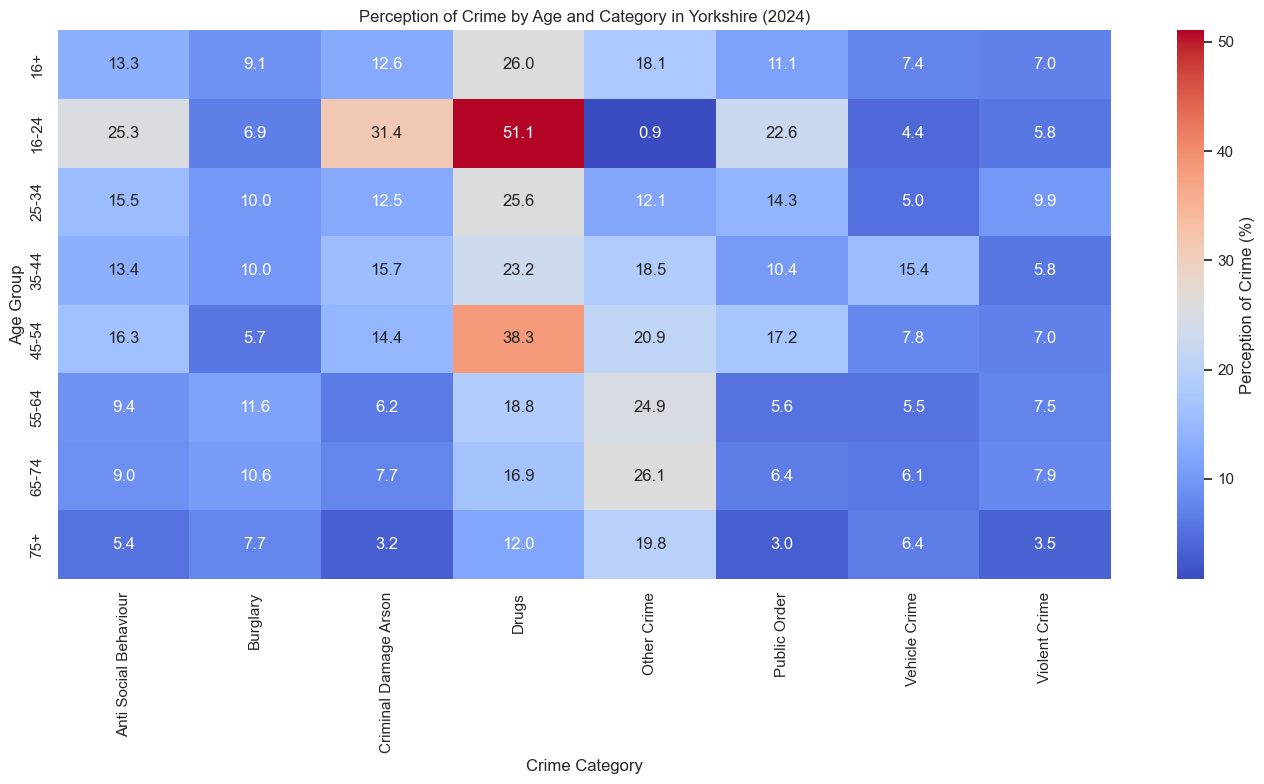

In [20]:
# Create a heatmap for perceptions of crime by age and category with crime categories on the x-axis
plt.figure(figsize=(14, 8))
sns.heatmap(age_grouped.pivot(index='Age', columns='CrimeCategory', values='Estimate'), 
            annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Perception of Crime (%)'})
plt.title('Perception of Crime by Age and Category in Yorkshire (2024)')
plt.xlabel('Crime Category')
plt.ylabel('Age Group')
plt.xticks()
plt.tight_layout()
plt.savefig('images/perception_of_crime_by_age_and_category.png', dpi=300, bbox_inches='tight')
plt.show()


Population as of 2024
- South Yorkshire 1,374,200
- North Yorkshire 618,627
- West Yorkshire 2,402,161

In [21]:
# Copy the existing pivot table to avoid modifying original
crime_percent = crime_pivot_total.copy()

# Identify the police force columns (skip 'category')
force_columns = crime_percent.columns.drop('category')

# Add new columns with '% Incident Rate' per force
for col in force_columns:
    crime_percent[f'{col} % Incident Rate'] = crime_percent[col] / 10

# View the updated DataFrame
crime_percent


force_name,category,North Yorkshire,South Yorkshire,West Yorkshire,North Yorkshire % Incident Rate,South Yorkshire % Incident Rate,West Yorkshire % Incident Rate
0,Anti Social Behaviour,204,1,283,20.4,0.1,28.3
1,Bicycle Theft,4,42,21,0.4,4.2,2.1
2,Burglary,7,690,78,0.7,69.0,7.8
3,Criminal Damage Arson,16,689,201,1.6,68.9,20.1
4,Drugs,16,569,232,1.6,56.9,23.2
5,Other Crime,11,227,368,1.1,22.7,36.8
6,Other Theft,11,481,249,1.1,48.1,24.9
7,Possession Of Weapons,2,194,45,0.2,19.4,4.5
8,Public Order,17,782,302,1.7,78.2,30.2
9,Robbery,1,237,44,0.1,23.7,4.4


In [22]:
# Match perceptions_df with crime_percent on 'category', creating columns for each force's incident rate
# create a new DataFrame to hold the merged data
merged_df = pd.merge(age_grouped, crime_percent, left_on='CrimeCategory', right_on='category', how='left')
# Select relevant columns for the merged DataFrame
merged_df = merged_df[['Age', 'CrimeCategory', 'Estimate'] + [f'{force} % Incident Rate' for force in forces.values()]] 

merged_df

,Age,CrimeCategory,Estimate,South Yorkshire % Incident Rate,West Yorkshire % Incident Rate,North Yorkshire % Incident Rate
0,16+,Anti Social Behaviour,13.280667,0.1,28.3,20.4
1,16+,Burglary,9.126667,69.0,7.8,0.7
2,16+,Criminal Damage Arson,12.583333,68.9,20.1,1.6
3,16+,Drugs,25.986667,56.9,23.2,1.6
4,16+,Other Crime,18.050000,22.7,36.8,1.1
...,...,...,...,...,...,...
59,75+,Drugs,11.973333,56.9,23.2,1.6
60,75+,Other Crime,19.760000,22.7,36.8,1.1
61,75+,Public Order,2.963333,78.2,30.2,1.7
62,75+,Vehicle Crime,6.400000,60.5,15.0,0.5


C:\Users\ickle\AppData\Local\Temp\ipykernel_15628\1295136987.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[force_col] = df_filtered[force_col] / 10  # Now it's per 100 people, i.e., %


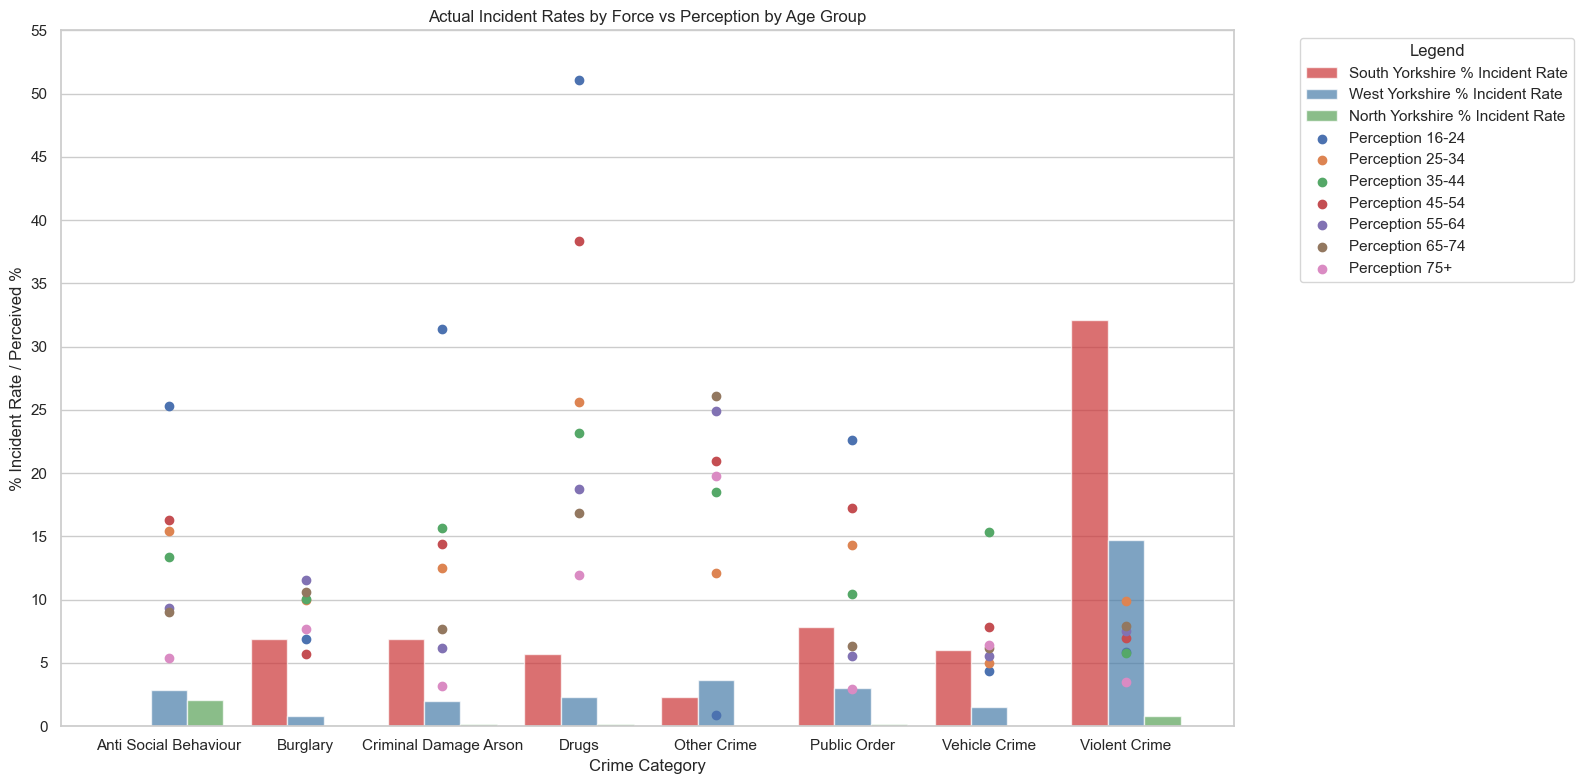

In [23]:
# Merge perceptions with crime incident rates
merged_df = pd.merge(age_grouped, crime_percent, left_on='CrimeCategory', right_on='category', how='left')

# Select relevant columns
merged_df = merged_df[['Age', 'CrimeCategory', 'Estimate'] + [f'{force} % Incident Rate' for force in forces.values()]]

# Filter out '16+' age group
df_filtered = merged_df[merged_df['Age'] != '16+']

# 🔧 SCALE INCIDENT RATES to percentages by dividing by 10 (since they’re per 1,000)
for force_col in [f'{force} % Incident Rate' for force in forces.values()]:
    df_filtered[force_col] = df_filtered[force_col] / 10  # Now it's per 100 people, i.e., %

# Calculate average actual incident rate per force per category
avg_actuals = df_filtered.groupby('CrimeCategory')[[f'{force} % Incident Rate' for force in forces.values()]].mean().reset_index()

# Melt for barplot
actuals_melted = avg_actuals.melt(
    id_vars='CrimeCategory',
    var_name='Force',
    value_name='Actual %'
)

# Prepare perception data
perception = df_filtered[['CrimeCategory', 'Age', 'Estimate']]

# 📊 Plot
plt.figure(figsize=(16, 8)) 

# Barplot: actual incident rate per force
sns.barplot(data=actuals_melted, x='CrimeCategory', y='Actual %', hue='Force', alpha=0.7, palette='Set1')

# Overlay: perception as scatter (per age group)
age_groups = perception['Age'].unique()
for age in age_groups:
    subset = perception[perception['Age'] == age]
    plt.scatter(subset['CrimeCategory'], subset['Estimate'], marker='o', label=f'Perception {age}')

# Aesthetics
plt.xticks()
plt.title('Actual Incident Rates by Force vs Perception by Age Group')
plt.ylabel('% Incident Rate / Perceived %')
plt.xlabel('Crime Category')

# 🔧 Set y-axis ticks in steps of 5 up to a bit more than the max value
max_val = max(actuals_melted['Actual %'].max(), perception['Estimate'].max())
plt.yticks(np.arange(0, round(max_val + 5), 5))  # rounds up and sets range in 5s

plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/actual_vs_perception.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

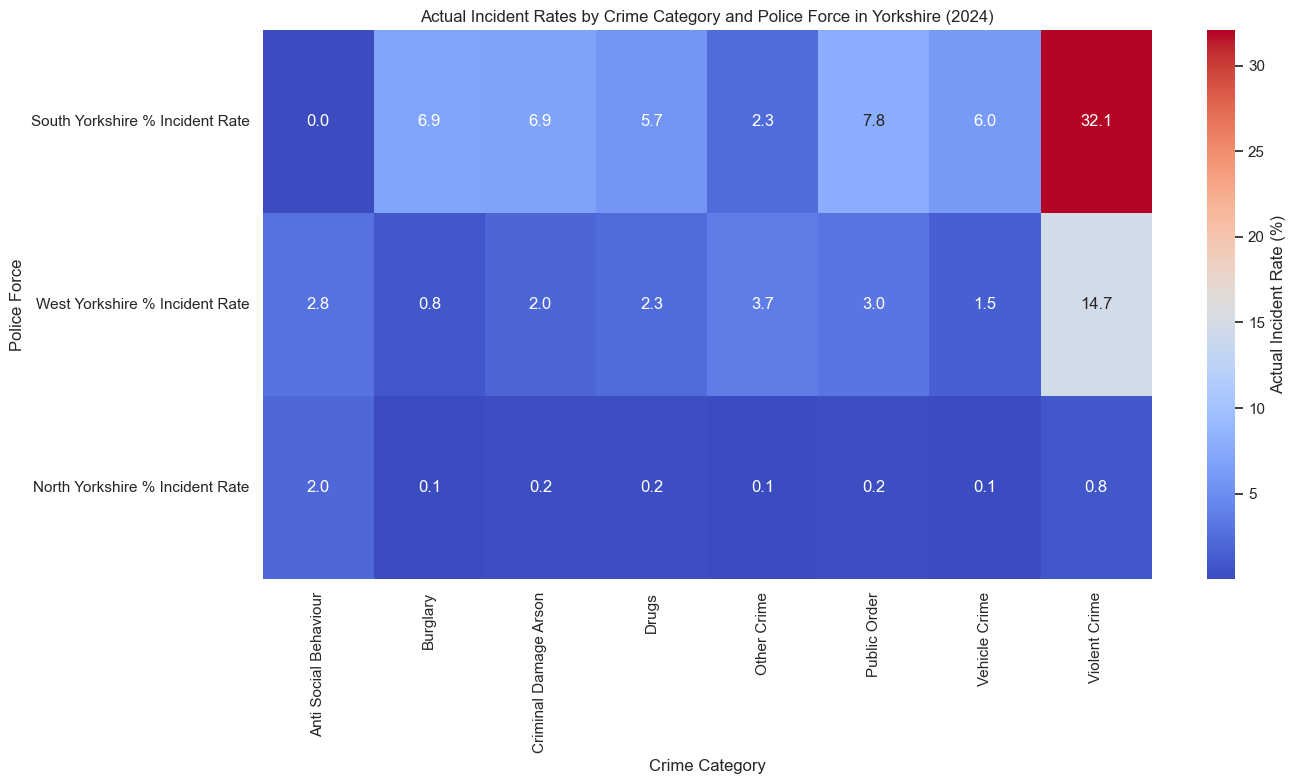

In [25]:
#create a heatmap for actual incident rates by crime category and police force
plt.figure(figsize=(14, 8)) 
sns.heatmap(avg_actuals.set_index('CrimeCategory').T, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Actual Incident Rate (%)'})
plt.title('Actual Incident Rates by Crime Category and Police Force in Yorkshire (2024)')
plt.xlabel('Crime Category')
plt.ylabel('Police Force')
plt.xticks()
plt.tight_layout()
plt.savefig('images/actual_incident_rates_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

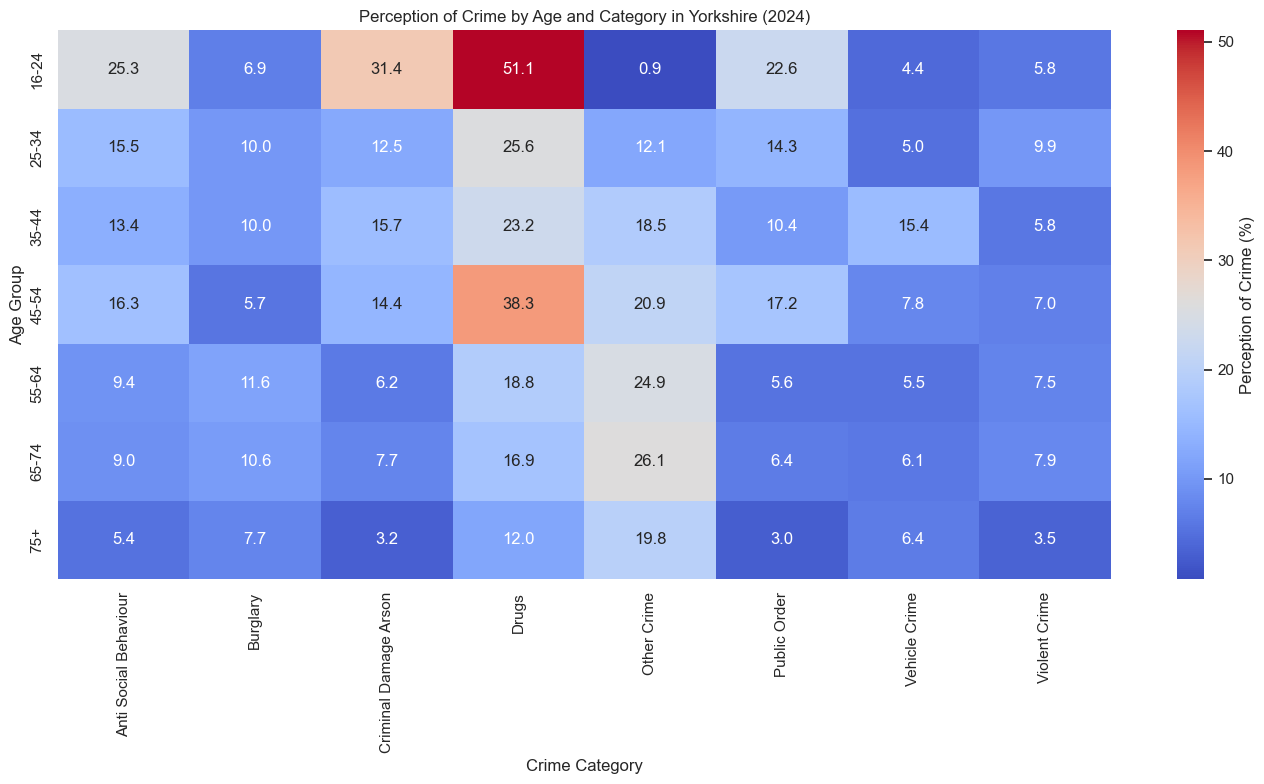

In [26]:
#create a heatmap for perception vs actual incident rates by crime category and police force
plt.figure(figsize=(14, 8)) 
sns.heatmap(df_filtered.pivot(index='Age', columns='CrimeCategory', values='Estimate'), 
            annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Perception of Crime (%)'})
plt.title('Perception of Crime by Age and Category in Yorkshire (2024)')
plt.xlabel('Crime Category')
plt.ylabel('Age Group')
plt.xticks()
plt.tight_layout()
plt.savefig('images/perception_of_crime_by_age_and_category_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()